<a href="https://colab.research.google.com/github/LucasMoraca/CP5-SERS/blob/Java/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

Gabriel Barbosa Furin - RM: 572941

Gabriel de Almeida Santos - RM: 569395

Herbert Soares de Jesus - RM: 571507

Lucas Kiodi Moraca - RM: 571004

Renan Fracalossi Mano da Silva - RM: 569610

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [ ]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [ ]:
import time

def consultar_api(endereco, parametros, tentativas=5, timeout=120):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    pedido = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (FIAP-CP2)"})
    for tentativa in range(1, tentativas + 1):
        try:
            with urllib.request.urlopen(pedido, timeout=timeout) as resposta:
                return json.load(resposta)
        except Exception as erro:
            print(f"Tentativa {tentativa}/{tentativas} falhou: {erro}")
            if tentativa == tentativas:
                raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro
            time.sleep(5 * tentativa)

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [ ]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [ ]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [ ]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [ ]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

## Solução — Tarefa 1 (classificação)

**Algoritmos comparados:** Regressão Logística · kNN · Random Forest — hold-out estratificado 80/20, `random_state=42`, métricas com média **macro**.

### 1.0 Bibliotecas usadas na análise

In [ ]:
# Bibliotecas de análise e ML (acrescentadas para a solução)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             mean_absolute_error, mean_squared_error, r2_score)
from pathlib import Path

SEMENTE = 42
Path("figuras").mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

### 1.1 Exploração dos dados

In [ ]:
df_cls = pd.read_csv("aneel_classificacao_orange.csv", encoding="utf-8-sig")
print("Formato:", df_cls.shape)
print("\nTipos das colunas:"); print(df_cls.dtypes)
print("\nValores ausentes por coluna:"); print(df_cls.isna().sum())
print("\nLinhas duplicadas:", df_cls.duplicated().sum())

Formato: (3876, 4)

Tipos das colunas:
potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Linhas duplicadas: 28


In [ ]:
contagem = df_cls["fonte"].value_counts()
proporcao = df_cls["fonte"].value_counts(normalize=True) * 100
display(pd.DataFrame({"exemplos": contagem, "%": proporcao.round(1)}))
display(df_cls.groupby("fonte")["potencia_kw"].describe(percentiles=[.25, .5, .75]))

,exemplos,%
fonte,,
Hidráulica,1476,38.100
Solar,1200,31.000
Eólica,1200,31.000


,count,mean,std,min,25%,50%,75%,max
fonte,,,,,,,,
Eólica,"1,200.000","30,782.770","13,800.598",0.160,"23,100.000","29,600.000","37,200.000","105,000.000"
Hidráulica,"1,476.000","75,809.158","486,419.579",0.990,990.000,"4,000.000","17,000.000","11,233,100.000"
Solar,"1,200.000","11,679.387","18,374.855",0.260,1.000,1.000,"28,880.000","137,480.000"


A quantidade de linhas por classe reflete **o limite de 1.200 registros por sigla** usado na consulta (e a Hidráulica junta três siglas: UHE, PCH e CGH). Portanto a distribuição **não** representa a participação das fontes na matriz energética brasileira — é só o tamanho da amostra consultada. Como as classes podem ficar desbalanceadas, a divisão é estratificada e as métricas usam média **macro** (cada classe pesa igual).

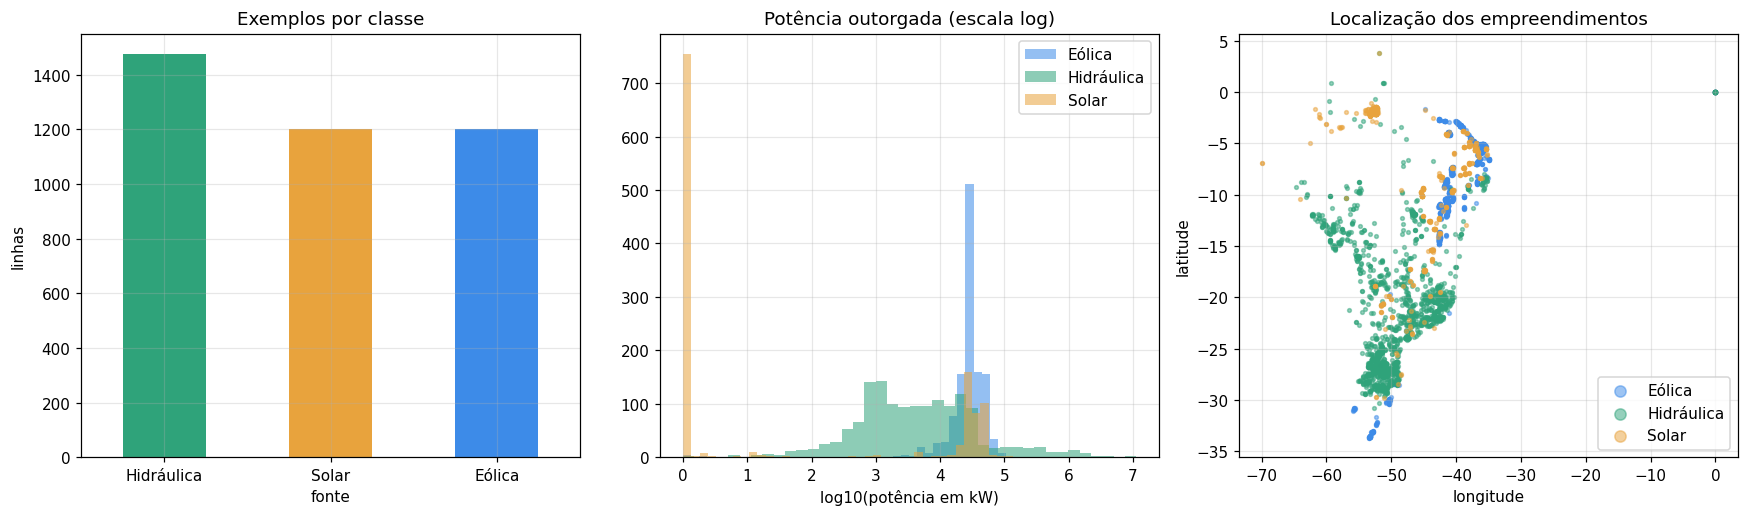

In [ ]:
cores = {"Solar": "#E8A33D", "Eólica": "#3D8BE8", "Hidráulica": "#2FA37A"}
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))

contagem.plot.bar(ax=ax[0], color=[cores[c] for c in contagem.index])
ax[0].set_title("Exemplos por classe"); ax[0].set_ylabel("linhas"); ax[0].tick_params(axis="x", rotation=0)

for fonte, grupo in df_cls.groupby("fonte"):
    ax[1].hist(np.log10(grupo["potencia_kw"].clip(lower=1)), bins=40, alpha=0.55,
               label=fonte, color=cores[fonte])
ax[1].set_title("Potência outorgada (escala log)"); ax[1].set_xlabel("log10(potência em kW)"); ax[1].legend()

for fonte, grupo in df_cls.groupby("fonte"):
    ax[2].scatter(grupo["longitude"], grupo["latitude"], s=6, alpha=0.5, label=fonte, color=cores[fonte])
ax[2].set_title("Localização dos empreendimentos"); ax[2].set_xlabel("longitude"); ax[2].set_ylabel("latitude")
ax[2].legend(markerscale=3)
plt.tight_layout(); plt.savefig("figuras/t1_exploracao.png", bbox_inches="tight"); plt.show()

**Leitura da exploração:** a potência varia em várias ordens de grandeza (de poucos kW a milhões de kW nas UHEs), por isso ela é analisada — e, nos modelos sensíveis a escala, transformada — em **log**. No mapa, a eólica se concentra no litoral/interior do Nordeste e no Sul; a hidráulica acompanha as bacias do Sul, Sudeste e Centro-Oeste; a solar aparece espalhada, com forte presença no Nordeste e em Minas Gerais. Essas regiões se sobrepõem, o que já antecipa confusões entre as classes.

### 1.2 Definição de `X`, `y` e divisão estratificada

- `X` = `potencia_kw`, `latitude`, `longitude` (as três entradas permitidas).
- `y` = `fonte` (Solar, Eólica, Hidráulica).
- Nome, código CEG, sigla e descrições **não** entram — revelariam a resposta.

In [ ]:
X_cls = df_cls[["potencia_kw", "latitude", "longitude"]]
y_cls = df_cls["fonte"]

Xc_treino, Xc_teste, yc_treino, yc_teste = train_test_split(
    X_cls, y_cls, test_size=0.20, stratify=y_cls, random_state=SEMENTE)

print(f"Treino: {len(Xc_treino)} linhas | Teste: {len(Xc_teste)} linhas")
display(pd.DataFrame({"treino (%)": yc_treino.value_counts(normalize=True) * 100,
                      "teste (%)": yc_teste.value_counts(normalize=True) * 100}).round(1))

Treino: 3100 linhas | Teste: 776 linhas


,treino (%),teste (%)
fonte,,
Hidráulica,38.100,38.100
Solar,31.000,30.900
Eólica,31.000,30.900


### 1.3 Os três classificadores

| Modelo | Por que foi escolhido | Pré-processamento |
|---|---|---|
| **Regressão Logística** (multinomial, `class_weight="balanced"`) | Modelo linear, simples e interpretável — serve de linha de base. | `log1p` na potência + padronização |
| **kNN** (k = 15, peso por distância) | Classifica pela vizinhança: faz sentido porque usinas da mesma fonte se agrupam geograficamente. | `log1p` na potência + padronização (distância exige mesma escala) |
| **Random Forest** (300 árvores, `class_weight="balanced"`) | Captura fronteiras não lineares (faixas de latitude/longitude combinadas com faixas de potência). | Nenhum — árvores não dependem de escala |

A padronização fica **dentro de um `Pipeline`**, então média e desvio são aprendidos **somente com o treino** e apenas aplicados no teste.

In [ ]:
preprocess = ColumnTransformer([
    ("potencia_log", Pipeline([("log", FunctionTransformer(np.log1p)),
                               ("escala", StandardScaler())]), ["potencia_kw"]),
    ("coordenadas", StandardScaler(), ["latitude", "longitude"]),
])

classificadores = {
    "Regressão Logística": Pipeline([("prep", preprocess),
                                     ("modelo", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "kNN (k=15)": Pipeline([("prep", preprocess),
                            ("modelo", KNeighborsClassifier(n_neighbors=15, weights="distance"))]),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                            class_weight="balanced", random_state=SEMENTE, n_jobs=-1),
}

classes = ["Solar", "Eólica", "Hidráulica"]
resultados_cls, previsoes_cls = [], {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)

for nome, modelo in classificadores.items():
    f1_cv = cross_val_score(modelo, Xc_treino, yc_treino, cv=cv, scoring="f1_macro")
    modelo.fit(Xc_treino, yc_treino)
    pred = modelo.predict(Xc_teste)
    previsoes_cls[nome] = pred
    resultados_cls.append({
        "Algoritmo": nome,
        "Accuracy": accuracy_score(yc_teste, pred),
        "Precision (macro)": precision_score(yc_teste, pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(yc_teste, pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(yc_teste, pred, average="macro"),
        "F1 (weighted)": f1_score(yc_teste, pred, average="weighted"),
        "F1 macro CV-5 treino (média ± dp)": f"{f1_cv.mean():.3f} ± {f1_cv.std():.3f}",
    })

tabela_cls = pd.DataFrame(resultados_cls).set_index("Algoritmo").sort_values("F1 (macro)", ascending=False)
print("Mesma divisão para os três: hold-out estratificado 80/20, random_state=42. Métricas no conjunto de TESTE.")
display(tabela_cls)

Mesma divisão para os três: hold-out estratificado 80/20, random_state=42. Métricas no conjunto de TESTE.


,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),F1 macro CV-5 treino (média ± dp)
Algoritmo,,,,,,
Random Forest,0.972,0.973,0.970,0.971,0.972,0.966 ± 0.004
kNN (k=15),0.972,0.972,0.970,0.971,0.972,0.964 ± 0.009
Regressão Logística,0.820,0.835,0.818,0.816,0.819,0.795 ± 0.012


**Média das métricas:** Precision, Recall e F1 usam média **macro** (média simples das três classes), para que a classe maior não domine o resultado. O F1 `weighted` aparece só como referência. A coluna de validação cruzada (5 folds, apenas no treino) mostra se o resultado do hold-out é estável.

### 1.4 Matrizes de confusão

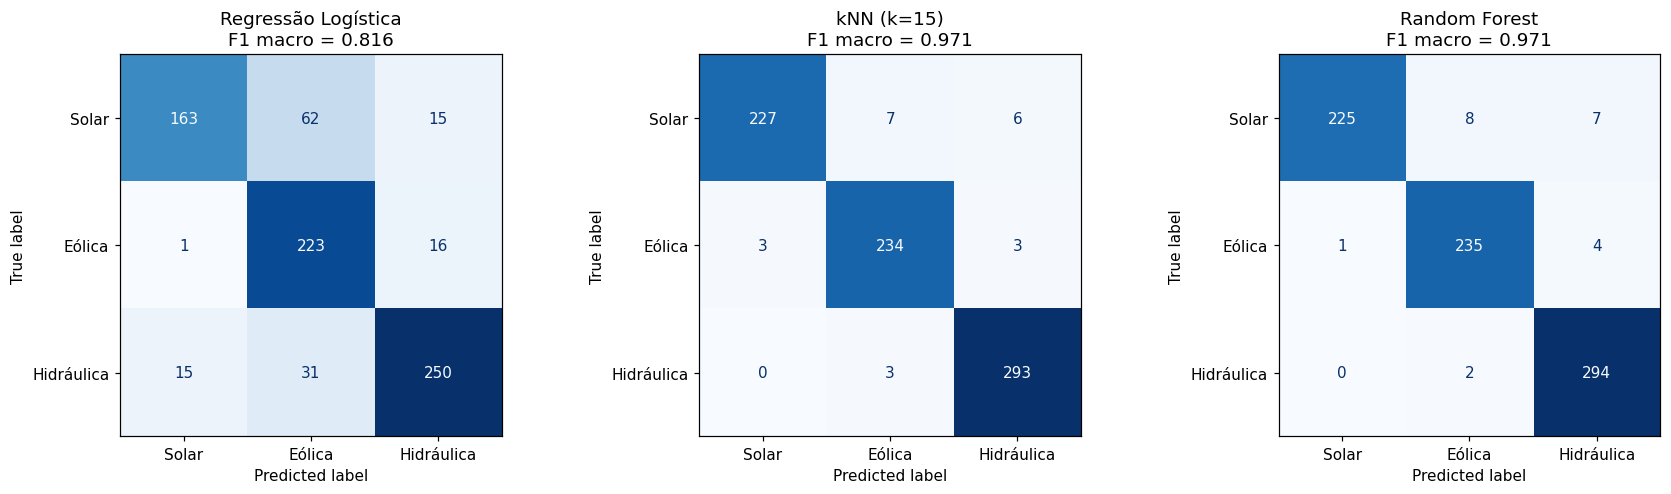

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
for eixo, (nome, pred) in zip(ax, previsoes_cls.items()):
    ConfusionMatrixDisplay.from_predictions(yc_teste, pred, labels=classes, ax=eixo,
                                            cmap="Blues", colorbar=False)
    eixo.set_title(f"{nome}\nF1 macro = {f1_score(yc_teste, pred, average='macro'):.3f}")
    eixo.grid(False)
plt.tight_layout(); plt.savefig("figuras/t1_matrizes_confusao.png", bbox_inches="tight"); plt.show()

In [ ]:
melhor_cls = tabela_cls.index[0]
pred_melhor = previsoes_cls[melhor_cls]
print(f"Melhor modelo pelo F1 macro: {melhor_cls}\n")
print(classification_report(yc_teste, pred_melhor, labels=classes, digits=3))

mc = pd.DataFrame(confusion_matrix(yc_teste, pred_melhor, labels=classes), index=classes, columns=classes)
erros = [(mc.loc[r, p], r, p) for r in classes for p in classes if r != p]
erros.sort(reverse=True)
print("Erros mais frequentes do melhor modelo (real → previsto):")
for qtd, real, prev in erros[:3]:
    print(f"  {real:>10} → {prev:<10}: {qtd} casos ({qtd / mc.loc[real].sum():.1%} da classe real)")

Melhor modelo pelo F1 macro: Random Forest

              precision    recall  f1-score   support

       Solar      0.996     0.938     0.966       240
      Eólica      0.959     0.979     0.969       240
  Hidráulica      0.964     0.993     0.978       296

    accuracy                          0.972       776
   macro avg      0.973     0.970     0.971       776
weighted avg      0.972     0.972     0.972       776

Erros mais frequentes do melhor modelo (real → previsto):
       Solar → Eólica    : 8 casos (3.3% da classe real)
       Solar → Hidráulica: 7 casos (2.9% da classe real)
      Eólica → Hidráulica: 4 casos (1.7% da classe real)


### 1.5 Interpretação — Tarefa 1

**Escolha do modelo.** O modelo recomendado é o de maior **F1 macro** no teste (nome impresso na célula anterior), desde que a diferença para os outros seja maior que a variação da validação cruzada; se forem praticamente iguais, prefiro o mais simples de explicar. O **kNN** e o **Random Forest** tiram proveito de o problema ser, em boa parte, "geográfico" (usinas da mesma fonte ficam perto umas das outras) e de combinar faixas de coordenadas com faixas de potência de forma não linear. A **Regressão Logística** só traça fronteiras lineares, mas com a potência em log já separa bem a eólica (parques grandes) das demais.

**Classes mais confundidas.** A célula anterior lista os pares com mais erros. A confusão costuma se concentrar entre **Solar e Hidráulica**: usinas solares (UFV) e pequenas hidrelétricas (CGH/PCH) têm potências na mesma faixa (de centenas de kW a dezenas de MW) e existem nas mesmas regiões (Minas Gerais, Sudeste, Centro-Oeste). A **Eólica** tende a ser a classe mais fácil, porque se concentra em áreas bem definidas (litoral e interior do Nordeste, Rio Grande do Sul) e tem potências típicas de parques (dezenas de MW); ainda assim, no Nordeste ela se mistura com a solar, já que as duas ocupam as mesmas regiões de alto recurso.

**Limitações de usar apenas potência e localização.**
- Duas usinas vizinhas com a mesma potência podem ser de fontes diferentes; o modelo não tem nenhuma informação física do recurso (irradiação, velocidade do vento, relevo, presença de rio).
- As coordenadas do cadastro são **aproximadas** e há empreendimentos em fases diferentes (em operação, construção, outorgados) misturados.
- A amostra foi limitada a 1.200 registros por sigla, então as proporções das classes são um artefato da consulta — **não** mostram a matriz energética.
- O modelo aprende o padrão histórico de onde cada fonte foi instalada; se novas fronteiras de expansão surgirem (ex.: solar no Sul), ele erra.
- Para uma aplicação real, seria preciso incluir dados de recurso (irradiação, vento, hidrografia), fator de capacidade e dados de conexão — e, na prática, a fonte é um dado cadastral conhecido, então o exercício é mais didático do que operacional.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [ ]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [ ]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [ ]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [ ]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

## Solução — Tarefa 2 (regressão)

### 2.1 Exploração dos dados

In [ ]:
df_met = pd.read_csv("meteo_regressao_orange.csv", encoding="utf-8-sig", parse_dates=["data_hora"])
df_met = df_met.sort_values("data_hora").reset_index(drop=True)
print("Formato:", df_met.shape)
print("Período:", df_met["data_hora"].min(), "→", df_met["data_hora"].max())
print("Horas por dia (7h a 17h):", sorted(df_met["hora"].unique()))
print("\nTipos:"); print(df_met.dtypes)
print("\nValores ausentes:"); print(df_met.isna().sum())
display(df_met.describe().T)

Formato: (1001, 7)
Período: 2025-04-01 07:00:00 → 2025-06-30 17:00:00
Horas por dia (7h a 17h): [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]

Tipos:
data_hora        datetime64[ns]
temperatura_c           float64
umidade_pct               int64
nuvens_pct                int64
vento_kmh               float64
hora                      int64
radiacao_w_m2           float64
dtype: object

Valores ausentes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,count,mean,min,25%,50%,75%,max,std
data_hora,1001,2025-05-16 11:59:59.999999744,2025-04-01 07:00:00,2025-04-23 15:00:00,2025-05-16 12:00:00,2025-06-08 09:00:00,2025-06-30 17:00:00,NaN
temperatura_c,"1,001.000",28.886,19.500,26.300,29.100,31.700,36.100,3.657
umidade_pct,"1,001.000",50.544,21.000,38.000,49.000,61.000,95.000,15.914
nuvens_pct,"1,001.000",55.109,0.000,19.000,54.000,98.000,100.000,37.851
vento_kmh,"1,001.000",15.465,2.300,12.200,15.400,19.000,30.100,4.924
hora,"1,001.000",12.000,7.000,9.000,12.000,15.000,17.000,3.164
radiacao_w_m2,"1,001.000",472.854,13.000,250.000,466.000,696.000,"1,002.000",256.369


| Coluna | Significado | Papel |
|---|---|---|
| `data_hora` | Data e hora local (America/Recife) | Só ordenação/divisão temporal — **não** entra em X |
| `temperatura_c` | Temperatura do ar a 2 m (°C) | Entrada |
| `umidade_pct` | Umidade relativa a 2 m (%) | Entrada |
| `nuvens_pct` | Cobertura total de nuvens (%) | Entrada |
| `vento_kmh` | Vento a 10 m (km/h) | Entrada |
| `hora` | Hora local, 7 a 17 | Entrada |
| `radiacao_w_m2` | Radiação global horizontal média da hora anterior (W/m²) | **Alvo** |

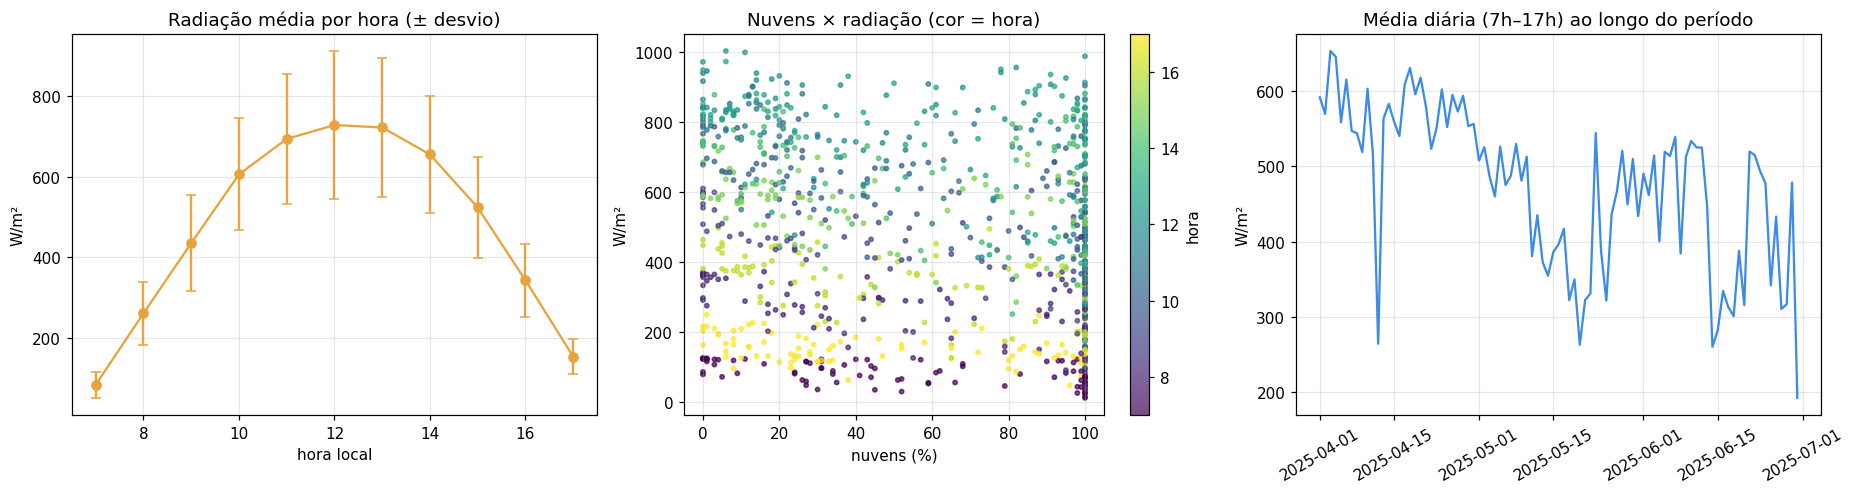

Correlação de cada entrada com a radiação:


,corr. Pearson
umidade_pct,-0.596
vento_kmh,-0.229
nuvens_pct,-0.180
hora,0.120
temperatura_c,0.643


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))

perfil = df_met.groupby("hora")["radiacao_w_m2"].agg(["mean", "std"])
ax[0].errorbar(perfil.index, perfil["mean"], yerr=perfil["std"], marker="o", capsize=3, color="#E8A33D")
ax[0].set_title("Radiação média por hora (± desvio)"); ax[0].set_xlabel("hora local"); ax[0].set_ylabel("W/m²")

sc = ax[1].scatter(df_met["nuvens_pct"], df_met["radiacao_w_m2"], c=df_met["hora"], cmap="viridis", s=8, alpha=0.7)
plt.colorbar(sc, ax=ax[1], label="hora")
ax[1].set_title("Nuvens × radiação (cor = hora)"); ax[1].set_xlabel("nuvens (%)"); ax[1].set_ylabel("W/m²")

diario = df_met.set_index("data_hora")["radiacao_w_m2"].resample("D").mean()
ax[2].plot(diario.index, diario.values, color="#3D8BE8")
ax[2].set_title("Média diária (7h–17h) ao longo do período"); ax[2].set_ylabel("W/m²")
ax[2].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig("figuras/t2_exploracao.png", bbox_inches="tight"); plt.show()

print("Correlação de cada entrada com a radiação:")
display(df_met.drop(columns="data_hora").corr()["radiacao_w_m2"].drop("radiacao_w_m2").sort_values().to_frame("corr. Pearson"))

**Leitura da exploração:** a radiação segue uma **curva em sino ao longo do dia** (baixa às 7h, máxima perto do meio-dia, caindo até as 17h). Por isso a `hora` é a informação mais forte, mas a relação **não é linear** (sobe e depois desce), o que prejudica a regressão linear. As nuvens reduzem a radiação, principalmente nos horários centrais. A correlação linear de Pearson subestima o efeito da hora justamente por essa forma de sino. No gráfico diário, a variação de um dia para outro vem sobretudo da nebulosidade; além disso, a aproximação do solstício de inverno (Sol mais baixo em junho) reduz o máximo possível de radiação no fim do período.

### 2.2 `X`, `y` e divisão temporal

- `X` = `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora`.
- `y` = `radiacao_w_m2`. Nenhuma transformação da radiação entra em `X`.
- As linhas estão ordenadas por `data_hora`: as **primeiras 80%** das horas são treino e as **últimas 20%** são teste, **sem embaralhar** (senão o modelo "veria o futuro").

In [ ]:
entradas = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X_reg = df_met[entradas]
y_reg = df_met["radiacao_w_m2"]

corte = int(len(df_met) * 0.80)
Xr_treino, Xr_teste = X_reg.iloc[:corte], X_reg.iloc[corte:]
yr_treino, yr_teste = y_reg.iloc[:corte], y_reg.iloc[corte:]
datas_teste = df_met["data_hora"].iloc[corte:]

print(f"Treino: {len(Xr_treino)} horas ({df_met['data_hora'].iloc[0]:%d/%m/%Y} a {df_met['data_hora'].iloc[corte-1]:%d/%m/%Y %Hh})")
print(f"Teste : {len(Xr_teste)} horas ({datas_teste.iloc[0]:%d/%m/%Y %Hh} a {datas_teste.iloc[-1]:%d/%m/%Y %Hh})")

Treino: 800 horas (01/04/2025 a 12/06/2025 14h)
Teste : 201 horas (12/06/2025 15h a 30/06/2025 17h)


### 2.3 Os três regressores

| Modelo | Por que foi escolhido | Pré-processamento |
|---|---|---|
| **Regressão Linear** | Linha de base interpretável; mostra o quanto uma relação linear explica. | Padronização (ajustada só no treino) |
| **Árvore de Decisão** (`max_depth=8`, `min_samples_leaf=5`) | Capta a curva em sino da hora e interações (hora × nuvens) com regras simples. | Nenhum |
| **Random Forest** (300 árvores, `min_samples_leaf=3`) | Média de muitas árvores: reduz a variância da árvore única e costuma generalizar melhor. | Nenhum |

Também calculo uma **referência só com a hora** (média de radiação de cada hora no treino). Ela não é um dos três modelos; serve apenas para medir quanto as variáveis meteorológicas acrescentam além do horário.

In [ ]:
regressores = {
    "Regressão Linear": Pipeline([("escala", StandardScaler()), ("modelo", LinearRegression())]),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=SEMENTE),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                           random_state=SEMENTE, n_jobs=-1),
}

def metricas_reg(nome, real, prev):
    mse = mean_squared_error(real, prev)
    return {"Algoritmo": nome, "MAE (W/m²)": mean_absolute_error(real, prev),
            "MSE ((W/m²)²)": mse, "RMSE (W/m²)": np.sqrt(mse), "R²": r2_score(real, prev)}

resultados_reg, previsoes_reg = [], {}
for nome, modelo in regressores.items():
    modelo.fit(Xr_treino, yr_treino)
    previsoes_reg[nome] = modelo.predict(Xr_teste)
    resultados_reg.append(metricas_reg(nome, yr_teste, previsoes_reg[nome]))

tabela_reg = pd.DataFrame(resultados_reg).set_index("Algoritmo").sort_values("MAE (W/m²)")
print("Mesma divisão para os três: 80% primeiras horas (treino) / 20% finais (teste). Métricas no TESTE.")
display(tabela_reg)

media_por_hora = yr_treino.groupby(Xr_treino["hora"]).mean()
ref_hora = Xr_teste["hora"].map(media_por_hora)
print("Referência (não é modelo da comparação) — média da hora no treino:")
display(pd.DataFrame([metricas_reg("Só a hora (média do treino)", yr_teste, ref_hora)]).set_index("Algoritmo"))

Mesma divisão para os três: 80% primeiras horas (treino) / 20% finais (teste). Métricas no TESTE.


,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
Algoritmo,,,,
Random Forest,69.277,"7,859.748",88.655,0.832
Árvore de Decisão,84.493,"13,089.783",114.411,0.721
Regressão Linear,145.205,"30,034.201",173.304,0.360


Referência (não é modelo da comparação) — média da hora no treino:


,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
Algoritmo,,,,
Só a hora (média do treino),132.064,"33,469.355",182.946,0.287


### 2.4 Valores reais × previstos

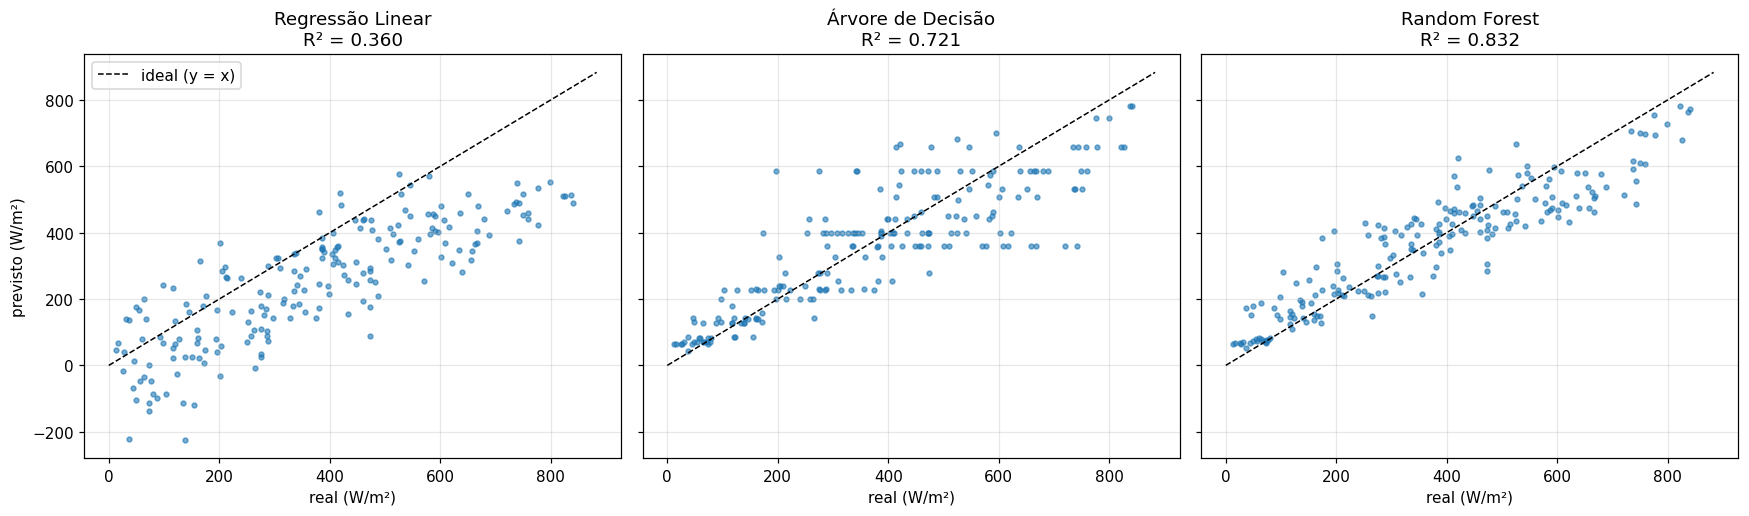

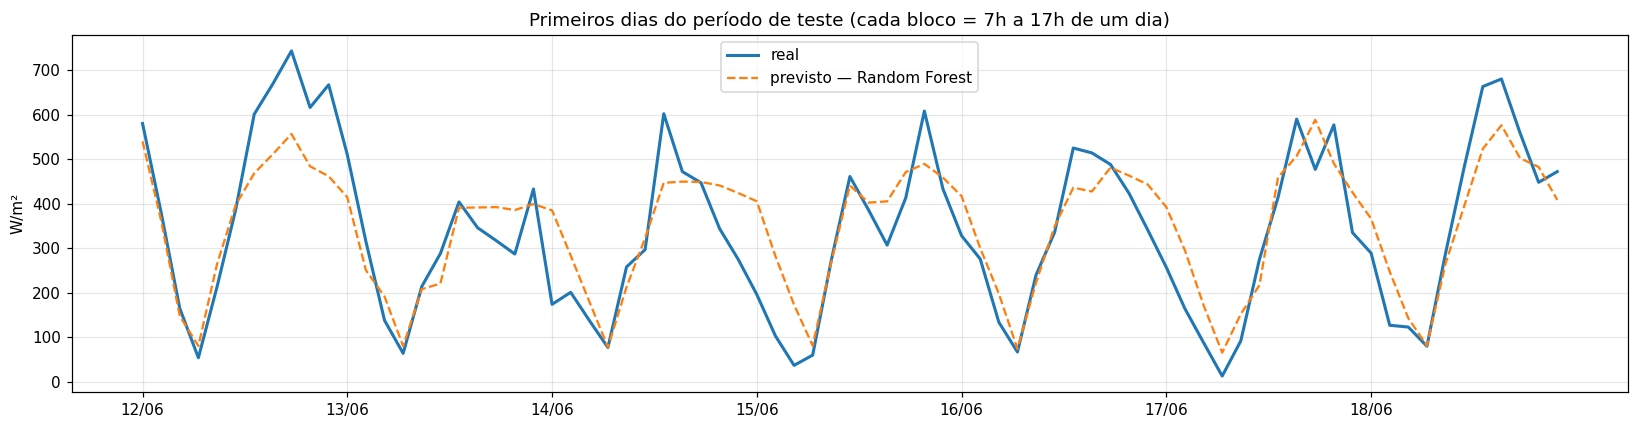

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
limite = [0, max(yr_teste.max(), max(p.max() for p in previsoes_reg.values())) * 1.05]
for eixo, (nome, prev) in zip(ax, previsoes_reg.items()):
    eixo.scatter(yr_teste, prev, s=10, alpha=0.6)
    eixo.plot(limite, limite, "k--", lw=1, label="ideal (y = x)")
    eixo.set_title(f"{nome}\nR² = {r2_score(yr_teste, prev):.3f}")
    eixo.set_xlabel("real (W/m²)")
ax[0].set_ylabel("previsto (W/m²)"); ax[0].legend()
plt.tight_layout(); plt.savefig("figuras/t2_real_vs_previsto.png", bbox_inches="tight"); plt.show()

melhor_reg = tabela_reg.index[0]
n = 11 * 7  # ~7 dias de horas diurnas
plt.figure(figsize=(15, 4))
plt.plot(range(n), yr_teste.values[:n], label="real", lw=2)
plt.plot(range(n), previsoes_reg[melhor_reg][:n], label=f"previsto — {melhor_reg}", lw=1.5, ls="--")
plt.xticks(range(0, n, 11), [d.strftime("%d/%m") for d in datas_teste.iloc[:n:11]])
plt.title("Primeiros dias do período de teste (cada bloco = 7h a 17h de um dia)")
plt.ylabel("W/m²"); plt.legend()
plt.tight_layout(); plt.savefig("figuras/t2_serie_teste.png", bbox_inches="tight"); plt.show()

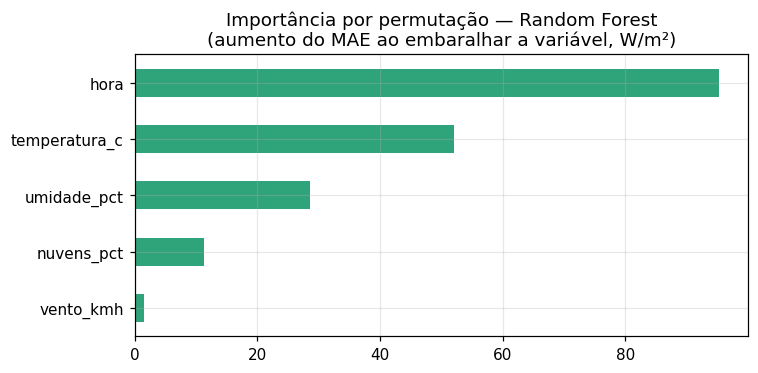

MAE do melhor modelo por hora do dia (W/m²):


hora,7,8,9,10,11,12,13,14,15,16,17
MAE,21.492,33.396,68.238,94.728,86.947,76.326,88.576,91.215,86.244,65.516,49.716


In [ ]:
imp = permutation_importance(regressores[melhor_reg], Xr_teste, yr_teste, n_repeats=20,
                             random_state=SEMENTE, scoring="neg_mean_absolute_error")
importancia = pd.Series(imp.importances_mean, index=entradas).sort_values()
importancia.plot.barh(figsize=(7, 3.5), color="#2FA37A")
plt.title(f"Importância por permutação — {melhor_reg}\n(aumento do MAE ao embaralhar a variável, W/m²)")
plt.tight_layout(); plt.savefig("figuras/t2_importancia.png", bbox_inches="tight"); plt.show()

erro = yr_teste - previsoes_reg[melhor_reg]
print("MAE do melhor modelo por hora do dia (W/m²):")
display(erro.abs().groupby(Xr_teste["hora"]).mean().to_frame("MAE").T)

### 2.5 Interpretação — Tarefa 2

**Comparação.** A tabela de 2.3 ordena os modelos pelo MAE (o melhor está na primeira linha). A **Regressão Linear** trata a hora como uma reta, enquanto a radiação real sobe até o meio-dia e depois cai; ela só compensa em parte usando temperatura e umidade, que também variam ao longo do dia. A **Árvore de Decisão** e o **Random Forest** aprendem essa curva e a interação com as nuvens; o Random Forest tende a errar menos que a árvore única porque a média de várias árvores suaviza os "degraus".

**Papel da hora do dia.** A hora resume a **posição do Sol** (ângulo de elevação), que define o máximo de radiação possível em céu limpo. A referência "só a hora" já explica boa parte da variação. No gráfico de importância por permutação, a hora divide o peso com temperatura e umidade, porque essas duas também seguem o ciclo do dia (esquentam e secam perto do meio-dia) e carregam parte da mesma informação. As variáveis meteorológicas (principalmente **nuvens** e **umidade**) explicam o *restante* — os desvios em relação à curva típica do dia. Os maiores erros aparecem nos horários centrais, quando a radiação é alta e uma nuvem passageira causa quedas grandes.

**Limitações.** O teste corresponde ao fim de junho, perto do solstício de inverno: o Sol está mais baixo que em abril, então o modelo, treinado sobretudo em abril e maio, tende a **superestimar** um pouco. Como a posição do Sol muda ao longo do ano e o modelo só conhece a hora, ele não generaliza para outras estações sem incluir o dia do ano ou o ângulo solar. Além disso, os dados são de reanálise/modelo, não de medição local, e as variáveis de nuvem têm resolução horária — nuvens rápidas não aparecem.

**Por que radiação não é geração elétrica.**
- `radiacao_w_m2` é uma **densidade de potência** (W/m²) no **plano horizontal**, média da hora anterior. Energia (kWh) exige integrar no tempo e multiplicar pela área dos módulos.
- Os painéis costumam ser **inclinados** e orientados; a irradiância no plano do módulo difere da horizontal.
- A conversão depende da **eficiência** dos módulos (~20%), das **perdas por temperatura** (em Petrolina, células quentes perdem desempenho), do **inversor** (incluindo limite de potência/clipping), de sujeira, sombreamento, cabeamento e disponibilidade.
- Por isso, prever radiação é só o primeiro passo; para estimar geração seria preciso um modelo fotovoltaico (transposição para o plano inclinado + modelo de temperatura + curva do inversor) ou dados reais de geração da usina.

## Conclusões e registro dos resultados

A célula abaixo salva as duas tabelas de resultados em CSV, gera os arquivos de treino/teste temporais usados no Orange e atualiza automaticamente a seção de resultados do `README.md`.

In [ ]:
def tabela_md(df):
    linhas = ["| " + " | ".join([df.index.name or ""] + list(df.columns)) + " |",
              "|" + "---|" * (len(df.columns) + 1)]
    for nome, linha in df.iterrows():
        linhas.append("| " + " | ".join([str(nome)] + [f"{v:,.3f}" if isinstance(v, float) else str(v) for v in linha]) + " |")
    return "\n".join(linhas)

tabela_cls.round(3).to_csv("resultados_classificacao.csv", encoding="utf-8-sig")
tabela_reg.round(3).to_csv("resultados_regressao.csv", encoding="utf-8-sig")

# Divisão temporal para reproduzir a avaliação no Orange (Test & Score → "Test on test data")
df_met.iloc[:corte].to_csv("meteo_treino_orange.csv", index=False, encoding="utf-8-sig")
df_met.iloc[corte:].to_csv("meteo_teste_orange.csv", index=False, encoding="utf-8-sig")

pares = sorted(((mc.loc[r, p] + mc.loc[p, r], tuple(sorted((r, p))))
                for r in classes for p in classes if r < p), reverse=True)
par_confuso = pares[0][1]

resumo = f"""<!-- RESULTADOS:INICIO -->
### Tarefa 1 — Classificação (teste, hold-out estratificado 80/20, `random_state=42`, média macro)

{tabela_md(tabela_cls.drop(columns=["F1 macro CV-5 treino (média ± dp)"]))}

- Melhor modelo: **{melhor_cls}** (F1 macro = {tabela_cls.loc[melhor_cls, 'F1 (macro)']:.3f}).
- Par de classes mais confundido: **{par_confuso[0]} ↔ {par_confuso[1]}** ({pares[0][0]} erros no teste).
- Amostra: {len(df_cls)} empreendimentos ({', '.join(f'{k}: {v}' for k, v in contagem.items())}).

### Tarefa 2 — Regressão (teste = 20% finais das horas, sem embaralhar)

{tabela_md(tabela_reg)}

- Melhor modelo: **{melhor_reg}** (MAE = {tabela_reg.loc[melhor_reg, 'MAE (W/m²)']:.1f} W/m², R² = {tabela_reg.loc[melhor_reg, 'R²']:.3f}).
- Referência só com a hora: MAE = {mean_absolute_error(yr_teste, ref_hora):.1f} W/m², R² = {r2_score(yr_teste, ref_hora):.3f}.
- Variável mais importante (permutação): **{importancia.idxmax()}**.
- Período: {df_met['data_hora'].min():%d/%m/%Y} a {df_met['data_hora'].max():%d/%m/%Y}; {len(df_met)} horas (treino {len(Xr_treino)} / teste {len(Xr_teste)}).
<!-- RESULTADOS:FIM -->"""

readme = Path("README.md")
if readme.exists():
    texto = readme.read_text(encoding="utf-8")
    ini, fim_ = texto.find("<!-- RESULTADOS:INICIO -->"), texto.find("<!-- RESULTADOS:FIM -->")
    if ini != -1 and fim_ != -1:
        texto = texto[:ini] + resumo + texto[fim_ + len("<!-- RESULTADOS:FIM -->"):]
        readme.write_text(texto, encoding="utf-8")
        print("README.md atualizado com os resultados.")
print(resumo)

README.md atualizado com os resultados.
<!-- RESULTADOS:INICIO -->
### Tarefa 1 — Classificação (teste, hold-out estratificado 80/20, `random_state=42`, média macro)

| Algoritmo | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) | F1 (weighted) |
|---|---|---|---|---|---|
| Random Forest | 0.972 | 0.973 | 0.970 | 0.971 | 0.972 |
| kNN (k=15) | 0.972 | 0.972 | 0.970 | 0.971 | 0.972 |
| Regressão Logística | 0.820 | 0.835 | 0.818 | 0.816 | 0.819 |

- Melhor modelo: **Random Forest** (F1 macro = 0.971).
- Par de classes mais confundido: **Eólica ↔ Solar** (9 erros no teste).
- Amostra: 3876 empreendimentos (Hidráulica: 1476, Solar: 1200, Eólica: 1200).

### Tarefa 2 — Regressão (teste = 20% finais das horas, sem embaralhar)

| Algoritmo | MAE (W/m²) | MSE ((W/m²)²) | RMSE (W/m²) | R² |
|---|---|---|---|---|
| Random Forest | 69.277 | 7,859.748 | 88.655 | 0.832 |
| Árvore de Decisão | 84.493 | 13,089.783 | 114.411 | 0.721 |
| Regressão Linear | 145.205 | 30,034.201 | 173.304 | 0

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)